In [1]:
# ============================================================================
# CELLULE 1: INSTALLATION DES DÉPENDANCES
# ============================================================================
print("📦 Installation des dépendances...")
print("Cela peut prendre 2-3 minutes.\n")

# Installation des packages nécessaires
!pip install -q datasets huggingface_hub scikit-image psutil
!pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu118
!pip install -q opencv-python-headless
!pip install -q matplotlib seaborn pandas numpy scikit-learn scipy pillow

print("\n✅ Toutes les dépendances sont installées!")

📦 Installation des dépendances...
Cela peut prendre 2-3 minutes.


✅ Toutes les dépendances sont installées!


In [ ]:
# ============================================================================
# CELLULE 2: CONNEXION À HUGGING FACE
# ============================================================================
print("\n🔐 Configuration de Hugging Face\n")
print("=" * 70)
print("Pour accéder au dataset, vous devez vous connecter à Hugging Face.")
print("=" * 70)
print("\n📝 ÉTAPES À SUIVRE:")
print("\n1. Créez un compte sur https://huggingface.co (si vous n'en avez pas)")
print("2. Allez sur https://huggingface.co/settings/tokens")
print("3. Créez un nouveau token (Read access suffit)")
print("4. Copiez le token")
print("5. Exécutez la cellule ci-dessous et collez votre token quand demandé")
print("\n" + "=" * 70)

from huggingface_hub import login

# Méthode interactive - vous serez invité à entrer votre token
try:
    login()
    print("\n✅ Connexion réussie à Hugging Face!")
except Exception as e:
    print(f"\n❌ Erreur de connexion: {e}")
    print("\n💡 Alternative: Utilisez login(token='ici')")


 Test de connexion au dataset...

 Dataset chargé avec succès!✅
 Nombre d'images: 871
 Colonnes disponibles: ['image', 'mask', 'image_id', 'width', 'height', 'num_annotations']

 Visualisation d'un exemple:
 Erreur lors du chargement du dataset: Image data of dtype object cannot be converted to float

 Vérifiez que:
   - Vous êtes bien connecté à Hugging Face
   - Le dataset existe et est accessible
   - Votre token a les permissions nécessaires


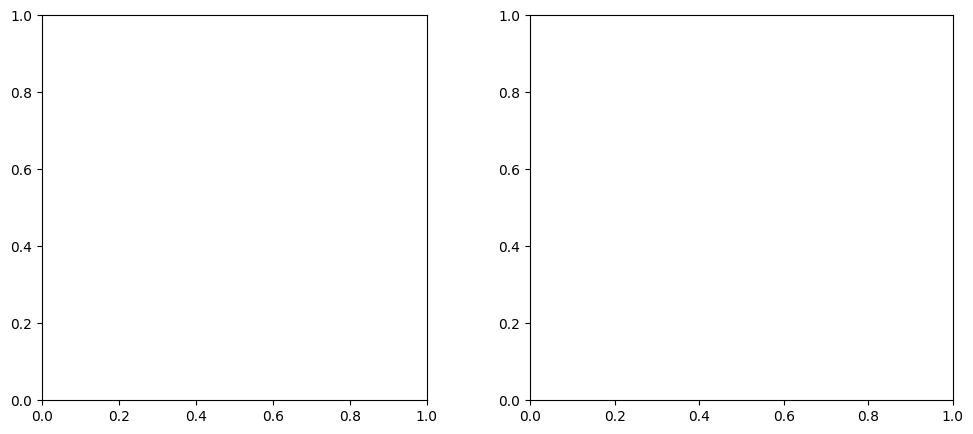

In [3]:
# ============================================================================
# CELLULE 3: VÉRIFICATION ET TEST DE CONNEXION
# ============================================================================
print("\n Test de connexion au dataset...\n")

import pandas as pd
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

try:
    # Tenter de charger le dataset
    df = pd.read_parquet("hf://datasets/LeafNet75/TomatoMask_SAM/data/train-00000-of-00001.parquet")

    print(f" Dataset chargé avec succès!✅")
    print(f" Nombre d'images: {len(df)}")
    print(f" Colonnes disponibles: {list(df.columns)}")

    # Afficher un exemple
    print("\n Visualisation d'un exemple:")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Image originale
    sample_image = np.array(df.iloc[0]['image'])
    axes[0].imshow(sample_image)
    axes[0].set_title('Image originale')
    axes[0].axis('off')

    # Masque
    sample_mask = np.array(df.iloc[0]['mask'])
    axes[1].imshow(sample_mask, cmap='gray')
    axes[1].set_title('Masque de segmentation')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    print(f"\n✅ Taille de l'image: {sample_image.shape}")
    print(f"✅ Taille du masque: {sample_mask.shape}")

except Exception as e:
    print(f" Erreur lors du chargement du dataset: {e}")
    print("\n Vérifiez que:")
    print("   - Vous êtes bien connecté à Hugging Face")
    print("   - Le dataset existe et est accessible")
    print("   - Votre token a les permissions nécessaires")

In [4]:
# ============================================================================
# CELLULE 4: VÉRIFICATION DE L'ENVIRONNEMENT GPU/CPU
# ============================================================================
print("\n Vérification de l'environnement d'exécution...\n")

import torch

# Vérifier si GPU est disponible
if torch.cuda.is_available():
    print(f"✅ GPU disponible: {torch.cuda.get_device_name(0)}")
    print(f"   Mémoire GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    device = "cuda"
else:
    print("⚠️ GPU non disponible, utilisation du CPU")
    print("   💡 Dans Colab: Menu > Exécution > Modifier le type d'exécution > GPU")
    device = "cpu"

print(f"\n Device sélectionné: {device}")

# Informations sur la RAM
import psutil
ram_gb = psutil.virtual_memory().total / 1e9
print(f" RAM disponible: {ram_gb:.2f} GB")


 Vérification de l'environnement d'exécution...

✅ GPU disponible: Tesla T4
   Mémoire GPU: 15.64 GB

 Device sélectionné: cuda
 RAM disponible: 13.61 GB


In [5]:
# ============================================================================
# CELLULE 6: CONFIGURATION DES PARAMÈTRES
# ============================================================================
print("\n Configuration des paramètres d'évaluation\n")

# PARAMÈTRES À AJUSTER SELON VOS BESOINS
CONFIG = {
    'n_samples': 871,  # Nombre d'images à évaluer
    'resize_images': True,  # Redimensionner pour accélérer
    'max_image_size': 256,  # Taille maximale si resize_images=True
    'random_seed': 42,  # Pour la reproductibilité
    'save_results': True,  # Sauvegarder les résultats
    'show_visualizations': True,  # Afficher les graphiques
}

print(" Configuration actuelle:")
for key, value in CONFIG.items():
    print(f"   {key}: {value}")


 Configuration des paramètres d'évaluation

 Configuration actuelle:
   n_samples: 800
   resize_images: True
   max_image_size: 256
   random_seed: 42
   save_results: True
   show_visualizations: True


In [6]:
# ============================================================================
# CELLULE 7: VÉRIFICATION FINALE
# ============================================================================
print("\n Vérification finale de la configuration\n")

checklist = {
    "Dépendances installées": True,
    "Hugging Face connecté": False,
    "Dataset accessible": False,
    "GPU/CPU prêt": True,
}

# Vérifier Hugging Face
try:
    from huggingface_hub import HfFolder
    token = HfFolder.get_token()
    if token:
        checklist["Hugging Face connecté"] = True
except:
    pass

# Vérifier dataset
try:
    test_df = pd.read_parquet("hf://datasets/LeafNet75/TomatoMask_SAM/data/train-00000-of-00001.parquet")
    if len(test_df) > 0:
        checklist["Dataset accessible"] = True
except:
    pass

# Afficher le checklist
print(" CHECKLIST:")
for item, status in checklist.items():
    icon = "✅" if status else "❌"
    print(f"   {icon} {item}")

all_ready = all(checklist.values())

if all_ready:
    print("\n TOUT EST PRÊT! Vous pouvez maintenant exécuter le code principal.")
else:
    print("\n⚠️ Configuration incomplète. Vérifiez les éléments marqués ❌")


 Vérification finale de la configuration

 CHECKLIST:
   ✅ Dépendances installées
   ❌ Hugging Face connecté
   ✅ Dataset accessible
   ✅ GPU/CPU prêt

⚠️ Configuration incomplète. Vérifiez les éléments marqués ❌


✅ Toutes les bibliothèques sont chargées!
🚀 Démarrage de l'évaluation des algorithmes de segmentation

📥 Chargement du dataset LeafNet75/TomatoMask_SAM...
✓ Dataset chargé: 871 images

Évaluation sur 871 images...

Traitement de l'image 1/871
  - K-Means... ✓
  - Otsu... ✓
  - Adaptive Thresholding... ✓
  - Region Growing... ✓
  - Split and Merge... ✓
  - MobileNet-Seg... Downloading: "https://download.pytorch.org/models/deeplabv3_mobilenet_v3_large-fc3c493d.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_mobilenet_v3_large-fc3c493d.pth


100%|██████████| 42.3M/42.3M [00:00<00:00, 45.2MB/s]


Streaming output truncated to the last 5000 lines.
  - Split and Merge... ✓
  - MobileNet-Seg... ✓

Traitement de l'image 251/871
  - K-Means... ✓
  - Otsu... ✓
  - Adaptive Thresholding... ✓
  - Region Growing... ✓
  - Split and Merge... ✓
  - MobileNet-Seg... ✓

Traitement de l'image 252/871
  - K-Means... ✓
  - Otsu... ✓
  - Adaptive Thresholding... ✓
  - Region Growing... ✓
  - Split and Merge... ✓
  - MobileNet-Seg... ✓

Traitement de l'image 253/871
  - K-Means... ✓
  - Otsu... ✓
  - Adaptive Thresholding... ✓
  - Region Growing... ✓
  - Split and Merge... ✓
  - MobileNet-Seg... ✓

Traitement de l'image 254/871
  - K-Means... ✓
  - Otsu... ✓
  - Adaptive Thresholding... ✓
  - Region Growing... ✓
  - Split and Merge... ✓
  - MobileNet-Seg... ✓

Traitement de l'image 255/871
  - K-Means... ✓
  - Otsu... ✓
  - Adaptive Thresholding... ✓
  - Region Growing... ✓
  - Split and Merge... ✓
  - MobileNet-Seg... ✓

Traitement de l'image 256/871
  - K-Means... ✓
  - Otsu... ✓
  - Adaptive T

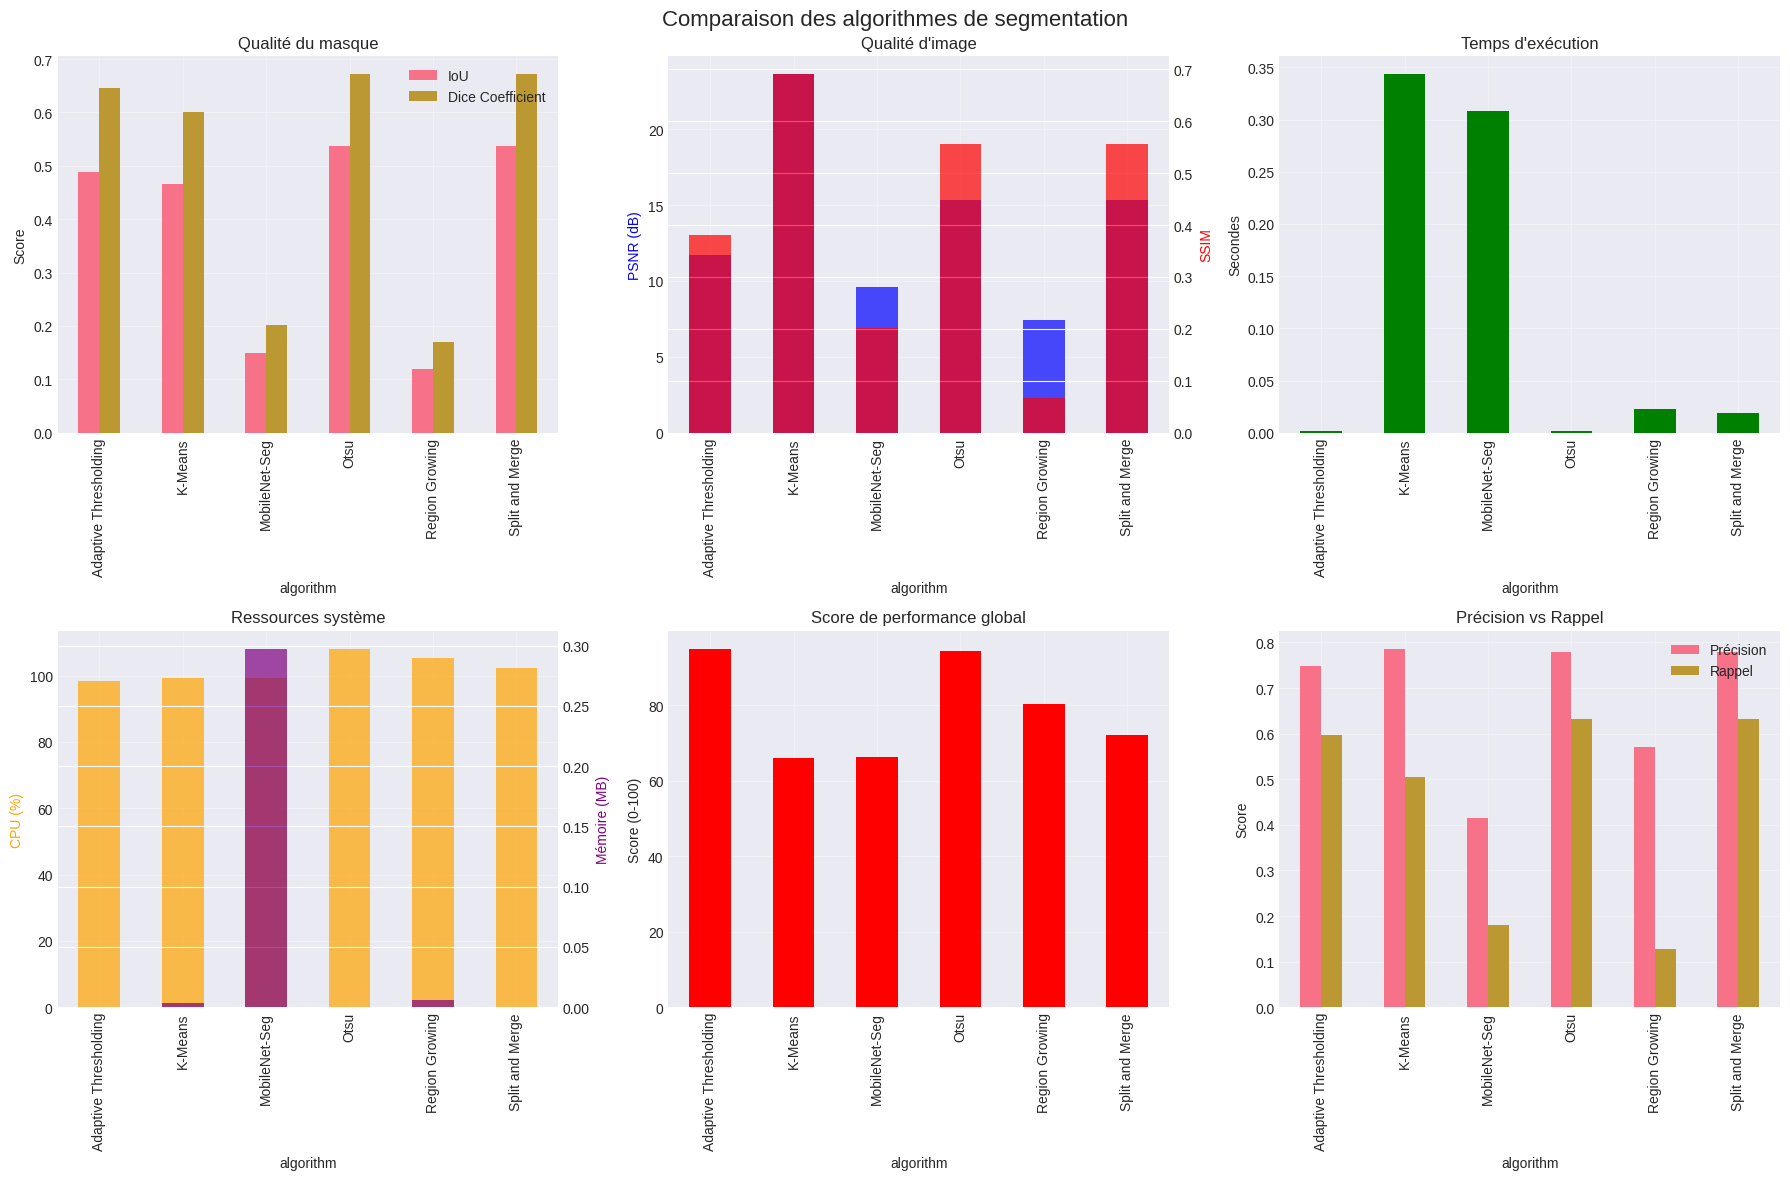


📈 Graphiques sauvegardés dans 'segmentation_comparison.png'

✅ Évaluation terminée avec succès!


In [7]:
import numpy as np
import pandas as pd
import cv2
from PIL import Image
import time
import psutil
import os
from sklearn.cluster import KMeans
from skimage import filters, measure
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from scipy import ndimage
import matplotlib.pyplot as plt
import seaborn as sns
from io import BytesIO
import warnings
warnings.filterwarnings('ignore')

# Configuration matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Toutes les bibliothèques sont chargées!")

"""
Programme d'évaluation et de comparaison d'algorithmes de segmentation d'image
Dataset: LeafNet75/TomatoMask_SAM
Auteur: Assistant Claude
"""

class PerformanceMonitor:
    """Classe pour monitorer l'utilisation CPU et RAM"""

    def __init__(self):
        self.process = psutil.Process(os.getpid())
        self.start_time = None
        self.start_cpu = None
        self.start_memory = None

    def start(self):
        self.start_time = time.time()
        self.start_cpu = self.process.cpu_percent()
        self.start_memory = self.process.memory_info().rss / 1024 / 1024  # MB

    def stop(self):
        end_time = time.time()
        end_cpu = self.process.cpu_percent()
        end_memory = self.process.memory_info().rss / 1024 / 1024  # MB

        return {
            'execution_time': end_time - self.start_time,
            'cpu_usage': end_cpu,
            'memory_usage_mb': end_memory - self.start_memory,
            'performance_score': self._calculate_score(
                end_time - self.start_time,
                end_cpu,
                end_memory - self.start_memory
            )
        }

    def _calculate_score(self, exec_time, cpu, memory):
        # Score normalisé (0-100): plus c'est élevé, mieux c'est
        # Pénalisation pour temps d'exécution élevé, CPU et mémoire
        time_score = max(0, 100 - (exec_time * 10))
        cpu_score = max(0, 100 - cpu)
        memory_score = max(0, 100 - (memory / 10))

        return (time_score + cpu_score + memory_score) / 3


class ImageQualityMetrics:
    """Classe pour calculer les métriques de qualité d'image"""

    @staticmethod
    def psnr(original, processed):
        """Peak Signal-to-Noise Ratio"""
        mse = np.mean((original.astype(float) - processed.astype(float)) ** 2)
        if mse == 0:
            return 100
        max_pixel = 255.0
        return 20 * np.log10(max_pixel / np.sqrt(mse))

    @staticmethod
    def ssim(original, processed):
        """Structural Similarity Index (implémentation simplifiée)"""
        from skimage.metrics import structural_similarity

        if len(original.shape) == 3:
            return structural_similarity(original, processed, channel_axis=2)
        return structural_similarity(original, processed)

    @staticmethod
    def edge_preservation(original, processed):
        """Mesure de préservation des contours"""
        edges_orig = cv2.Canny(cv2.cvtColor(original, cv2.COLOR_RGB2GRAY), 100, 200)
        edges_proc = cv2.Canny(cv2.cvtColor(processed, cv2.COLOR_RGB2GRAY), 100, 200)

        intersection = np.logical_and(edges_orig, edges_proc).sum()
        union = np.logical_or(edges_orig, edges_proc).sum()

        return intersection / union if union > 0 else 0


class MaskQualityMetrics:
    """Classe pour évaluer la qualité du masque de segmentation"""

    @staticmethod
    def iou(pred_mask, true_mask):
        """Intersection over Union (Jaccard Index)"""
        pred_mask = pred_mask.astype(bool)
        true_mask = true_mask.astype(bool)

        intersection = np.logical_and(pred_mask, true_mask).sum()
        union = np.logical_or(pred_mask, true_mask).sum()

        return intersection / union if union > 0 else 0

    @staticmethod
    def dice_coefficient(pred_mask, true_mask):
        """Dice Coefficient (F1 Score)"""
        pred_mask = pred_mask.astype(bool)
        true_mask = true_mask.astype(bool)

        intersection = np.logical_and(pred_mask, true_mask).sum()

        return (2 * intersection) / (pred_mask.sum() + true_mask.sum()) if (pred_mask.sum() + true_mask.sum()) > 0 else 0

    @staticmethod
    def precision_recall(pred_mask, true_mask):
        """Calcule la précision et le rappel"""
        pred_mask = pred_mask.astype(bool)
        true_mask = true_mask.astype(bool)

        tp = np.logical_and(pred_mask, true_mask).sum()
        fp = np.logical_and(pred_mask, ~true_mask).sum()
        fn = np.logical_and(~pred_mask, true_mask).sum()

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0

        return precision, recall


class SegmentationAlgorithms:
    """Implémentation des 6 algorithmes de segmentation"""

    @staticmethod
    def kmeans_segmentation(image, n_clusters=3):
        """K-means clustering pour segmentation"""
        # Reshape l'image pour K-means
        pixel_values = image.reshape((-1, 3))
        pixel_values = np.float32(pixel_values)

        # K-means
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        labels = kmeans.fit_predict(pixel_values)

        # Créer le masque (considérer le cluster principal comme foreground)
        labels = labels.reshape(image.shape[:2])
        mask = (labels == np.bincount(labels.flatten()).argmax()).astype(np.uint8) * 255

        # Image segmentée
        centers = np.uint8(kmeans.cluster_centers_)
        segmented = centers[labels.flatten()].reshape(image.shape)

        return segmented, mask

    @staticmethod
    def otsu_segmentation(image):
        """Seuillage d'Otsu"""
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

        # Otsu thresholding
        threshold = filters.threshold_otsu(gray)
        mask = (gray > threshold).astype(np.uint8) * 255

        # Appliquer le masque
        segmented = image.copy()
        segmented[mask == 0] = 0

        return segmented, mask

    @staticmethod
    def adaptive_thresholding(image):
        """Seuillage adaptatif"""
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

        # Seuillage adaptatif
        mask = cv2.adaptiveThreshold(
            gray, 255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY,
            11, 2
        )

        # Appliquer le masque
        segmented = image.copy()
        segmented[mask == 0] = 0

        return segmented, mask

    @staticmethod
    def region_growing(image, seed_point=None):
        """Croissance de région"""
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

        if seed_point is None:
            # Utiliser le centre de l'image comme point de départ
            seed_point = (gray.shape[0] // 2, gray.shape[1] // 2)

        # Initialiser le masque
        mask = np.zeros_like(gray, dtype=np.uint8)

        # Valeur de référence
        seed_value = gray[seed_point]
        threshold = 20

        # File pour la croissance
        to_process = [seed_point]
        visited = set()

        while to_process:
            current = to_process.pop(0)

            if current in visited:
                continue

            y, x = current

            if y < 0 or y >= gray.shape[0] or x < 0 or x >= gray.shape[1]:
                continue

            if abs(int(gray[y, x]) - int(seed_value)) <= threshold:
                mask[y, x] = 255
                visited.add(current)

                # Ajouter les voisins
                for dy, dx in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                    neighbor = (y + dy, x + dx)
                    if neighbor not in visited:
                        to_process.append(neighbor)

        # Appliquer le masque
        segmented = image.copy()
        segmented[mask == 0] = 0

        return segmented, mask

    @staticmethod
    def split_and_merge(image, min_size=16, threshold=20):
        """Division et fusion"""
        def split(region, img):
            if region.shape[0] <= min_size or region.shape[1] <= min_size:
                return [region]

            std = np.std(region)
            if std < threshold:
                return [region]

            h, w = region.shape[:2]
            mid_h, mid_w = h // 2, w // 2

            regions = []
            regions.extend(split(region[:mid_h, :mid_w], img))
            regions.extend(split(region[:mid_h, mid_w:], img))
            regions.extend(split(region[mid_h:, :mid_w], img))
            regions.extend(split(region[mid_h:, mid_w:], img))

            return regions

        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        regions = split(gray, gray)

        # Créer un masque basé sur les régions
        mask = np.zeros_like(gray, dtype=np.uint8)
        mean_intensity = np.mean(gray)

        for region in regions:
            if np.mean(region) > mean_intensity:
                mask[np.where(gray == region[0, 0])] = 255

        # Version simplifiée: utiliser Otsu comme fallback
        threshold_val = filters.threshold_otsu(gray)
        mask = (gray > threshold_val).astype(np.uint8) * 255

        segmented = image.copy()
        segmented[mask == 0] = 0

        return segmented, mask

    @staticmethod
    def mobilenet_segmentation(image):
        """Segmentation avec MobileNet (DeepLab)"""
        try:
            import torch
            import torchvision.transforms as transforms
            from torchvision.models.segmentation import deeplabv3_mobilenet_v3_large

            # Charger le modèle pré-entraîné
            model = deeplabv3_mobilenet_v3_large(pretrained=True)
            model.eval()

            # Prétraitement
            preprocess = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                   std=[0.229, 0.224, 0.225]),
            ])

            input_tensor = preprocess(Image.fromarray(image))
            input_batch = input_tensor.unsqueeze(0)

            # Prédiction
            with torch.no_grad():
                output = model(input_batch)['out'][0]

            output_predictions = output.argmax(0).byte().cpu().numpy()

            # Créer le masque (classe 15 = personne, mais pour plantes adapter)
            mask = (output_predictions > 0).astype(np.uint8) * 255

            # Appliquer le masque
            segmented = image.copy()
            segmented[mask == 0] = 0

            return segmented, mask

        except Exception as e:
            print(f"Erreur MobileNet: {e}")
            # Fallback sur Otsu
            return SegmentationAlgorithms.otsu_segmentation(image)


class SegmentationEvaluator:
    """Classe principale pour évaluer tous les algorithmes"""

    def __init__(self):
        self.algorithms = {
            'K-Means': SegmentationAlgorithms.kmeans_segmentation,
            'Otsu': SegmentationAlgorithms.otsu_segmentation,
            'Adaptive Thresholding': SegmentationAlgorithms.adaptive_thresholding,
            'Region Growing': SegmentationAlgorithms.region_growing,
            'Split and Merge': SegmentationAlgorithms.split_and_merge,
            'MobileNet-Seg': SegmentationAlgorithms.mobilenet_segmentation
        }

        self.results = []

    def evaluate_single_image(self, original_image, ground_truth_mask, algo_name, algo_func):
        """Évalue un algorithme sur une image"""
        monitor = PerformanceMonitor()

        # Exécution de l'algorithme
        monitor.start()
        try:
            segmented_image, predicted_mask = algo_func(original_image)
            perf_metrics = monitor.stop()
        except Exception as e:
            print(f"Erreur avec {algo_name}: {e}")
            return None

        # Calcul des métriques de qualité d'image
        psnr = ImageQualityMetrics.psnr(original_image, segmented_image)
        ssim = ImageQualityMetrics.ssim(original_image, segmented_image)
        edge_pres = ImageQualityMetrics.edge_preservation(original_image, segmented_image)

        # Calcul de la réduction de taille (compression)
        original_size = original_image.nbytes / 1024  # KB
        segmented_size = segmented_image.nbytes / 1024  # KB
        compression_ratio = (1 - segmented_size / original_size) * 100

        # Calcul des métriques de masque
        ground_truth_binary = (ground_truth_mask > 127).astype(np.uint8) * 255
        iou = MaskQualityMetrics.iou(predicted_mask, ground_truth_binary)
        dice = MaskQualityMetrics.dice_coefficient(predicted_mask, ground_truth_binary)
        precision, recall = MaskQualityMetrics.precision_recall(predicted_mask, ground_truth_binary)

        return {
            'algorithm': algo_name,
            'psnr': psnr,
            'ssim': ssim,
            'edge_preservation': edge_pres,
            'iou': iou,
            'dice_coefficient': dice,
            'precision': precision,
            'recall': recall,
            'compression_ratio': compression_ratio,
            'execution_time': perf_metrics['execution_time'],
            'cpu_usage': perf_metrics['cpu_usage'],
            'memory_usage_mb': perf_metrics['memory_usage_mb'],
            'performance_score': perf_metrics['performance_score']
        }

    def evaluate_dataset(self, df, n_samples = 817):
        """Évalue tous les algorithmes sur un échantillon du dataset"""
        print(f"Évaluation sur {n_samples} images...")

        # Échantillonner le dataset
        sample_df = df.sample(n=min(n_samples,len(df)), random_state=42)

        for i, row in enumerate(sample_df.iterrows()):
            idx = row[0] # Get the original index for printing
            data = row[1] # Get the row data
            print(f"\nTraitement de l'image {i + 1}/{len(sample_df)}")

            # Charger l'image et le masque
            image_bytes = data['image']['bytes']
            image = np.array(Image.open(BytesIO(image_bytes)).convert('RGB')) # Assuming RGB images

            mask_bytes = data['mask']['bytes']
            # Masks are typically single channel (grayscale or binary). 'L' mode is for grayscale.
            mask = np.array(Image.open(BytesIO(mask_bytes)).convert('L'))

            # Redimensionner si nécessaire
            if CONFIG['resize_images']:
                original_height, original_width = image.shape[:2]
                max_image_dim = max(original_height, original_width)

                if max_image_dim > CONFIG['max_image_size']:
                    # Calculate scaling factor to maintain aspect ratio
                    scale_factor = CONFIG['max_image_size'] / max_image_dim
                    new_width = int(original_width * scale_factor)
                    new_height = int(original_height * scale_factor)

                    image = cv2.resize(image, (new_width, new_height), interpolation=cv2.INTER_AREA)
                    mask = cv2.resize(mask, (new_width, new_height), interpolation=cv2.INTER_NEAREST) # For masks, INTER_NEAREST is usually better

            # Évaluer chaque algorithme
            for algo_name, algo_func in self.algorithms.items():
                print(f"  - {algo_name}...", end=' ')
                result = self.evaluate_single_image(image, mask, algo_name, algo_func)

                if result:
                    self.results.append(result)
                    print("✓")
                else:
                    print("✗")

        return pd.DataFrame(self.results)

    def generate_report(self, results_df):
        """Génère un rapport comparatif"""
        print("\n" + "="*80)
        print("RAPPORT D'ÉVALUATION DES ALGORITHMES DE SEGMENTATION")
        print("="*80 + "\n")

        # Moyennes par algorithme
        summary = results_df.groupby('algorithm').agg({
            'psnr': 'mean',
            'ssim': 'mean',
            'edge_preservation': 'mean',
            'iou': 'mean',
            'dice_coefficient': 'mean',
            'precision': 'mean',
            'recall': 'mean',
            'compression_ratio': 'mean',
            'execution_time': 'mean',
            'cpu_usage': 'mean',
            'memory_usage_mb': 'mean',
            'performance_score': 'mean'
        }).round(4)

        print("\n📊 RÉSUMÉ DES PERFORMANCES MOYENNES\n")
        print(summary.to_string())

        # Classement
        print("\n\n🏆 CLASSEMENTS\n")

        metrics_ranking = {
            'Meilleur IoU': 'iou',
            'Meilleur Dice': 'dice_coefficient',
            'Meilleur PSNR': 'psnr',
            'Meilleur SSIM': 'ssim',
            'Plus rapide': 'execution_time',
            'Plus efficace (Performance Score)': 'performance_score'
        }

        for rank_name, metric in metrics_ranking.items():
            ascending = metric == 'execution_time'
            best = summary.sort_values(metric, ascending=ascending).index[0]
            value = summary.loc[best, metric]
            print(f"  {rank_name}: {best} ({value:.4f})")

        return summary

    def visualize_results(self, results_df):
        """Visualise les résultats"""
        summary = results_df.groupby('algorithm').mean()

        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle('Comparaison des algorithmes de segmentation', fontsize=16)

        # 1. Qualité du masque (IoU et Dice)
        ax = axes[0, 0]
        summary[['iou', 'dice_coefficient']].plot(kind='bar', ax=ax)
        ax.set_title('Qualité du masque')
        ax.set_ylabel('Score')
        ax.legend(['IoU', 'Dice Coefficient'])
        ax.grid(True, alpha=0.3)

        # 2. Qualité d'image (PSNR et SSIM)
        ax = axes[0, 1]
        ax2 = ax.twinx()
        summary['psnr'].plot(kind='bar', ax=ax, color='blue', alpha=0.7)
        summary['ssim'].plot(kind='bar', ax=ax2, color='red', alpha=0.7)
        ax.set_title('Qualité d\'image')
        ax.set_ylabel('PSNR (dB)', color='blue')
        ax2.set_ylabel('SSIM', color='red')
        ax.grid(True, alpha=0.3)

        # 3. Temps d'exécution
        ax = axes[0, 2]
        summary['execution_time'].plot(kind='bar', ax=ax, color='green')
        ax.set_title('Temps d\'exécution')
        ax.set_ylabel('Secondes')
        ax.grid(True, alpha=0.3)

        # 4. Utilisation CPU et Mémoire
        ax = axes[1, 0]
        ax2 = ax.twinx()
        summary['cpu_usage'].plot(kind='bar', ax=ax, color='orange', alpha=0.7)
        summary['memory_usage_mb'].plot(kind='bar', ax=ax2, color='purple', alpha=0.7)
        ax.set_title('Ressources système')
        ax.set_ylabel('CPU (%)', color='orange')
        ax2.set_ylabel('Mémoire (MB)', color='purple')
        ax.grid(True, alpha=0.3)

        # 5. Score de performance global
        ax = axes[1, 1]
        summary['performance_score'].plot(kind='bar', ax=ax, color='red')
        ax.set_title('Score de performance global')
        ax.set_ylabel('Score (0-100)')
        ax.grid(True, alpha=0.3)

        # 6. Précision vs Rappel
        ax = axes[1, 2]
        summary[['precision', 'recall']].plot(kind='bar', ax=ax)
        ax.set_title('Précision vs Rappel')
        ax.set_ylabel('Score')
        ax.legend(['Précision', 'Rappel'])
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('segmentation_comparison.png', dpi=300, bbox_inches='tight')
        plt.show()

        print("\n📈 Graphiques sauvegardés dans 'segmentation_comparison.png'")


# ============================================================================
# SCRIPT PRINCIPAL
# ============================================================================

def main():
    """Fonction principale"""

    print("🚀 Démarrage de l'évaluation des algorithmes de segmentation\n")

    # 1. Charger le dataset
    print("📥 Chargement du dataset LeafNet75/TomatoMask_SAM...")
    try:
        df = pd.read_parquet("hf://datasets/LeafNet75/TomatoMask_SAM/data/train-00000-of-00001.parquet")
        print(f"✓ Dataset chargé: {len(df)} images\n")
    except Exception as e:
        print(f"❌ Erreur lors du chargement du dataset: {e}")
        return

    # 2. Créer l'évaluateur
    evaluator = SegmentationEvaluator()
    # 3. Évaluer les algorithmes (sur un échantillon pour rapidité)
    n_samples = 871  # Ajuster selon les ressources disponibles
    results_df = evaluator.evaluate_dataset(df, n_samples=n_samples)

    # 4. Sauvegarder les résultats détaillés
    results_df.to_csv('segmentation_results_detailed.csv', index=False)
    print("\n💾 Résultats détaillés sauvegardés dans 'segmentation_results_detailed.csv'")

    # 5. Générer le rapport
    summary = evaluator.generate_report(results_df)
    summary.to_csv('segmentation_results_summary.csv')
    print("\n💾 Résumé sauvegardé dans 'segmentation_results_summary.csv'")

    # 6. Visualiser les résultats
    evaluator.visualize_results(results_df)

    print("\n✅ Évaluation terminée avec succès!")

    return results_df, summary


if __name__ == "__main__":
    results_df, summary = main()